Importing Libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
DATA_DIR = Path("../data/raw/chest_xray")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print("Dataset path:", DATA_DIR)
print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Dataset path: ..\data\raw\chest_xray
Train path: ..\data\raw\chest_xray\train
Validation path: ..\data\raw\chest_xray\val
Test path: ..\data\raw\chest_xray\test


In [3]:
def count_images(folder):
    return len(list(folder.glob("*.jpeg"))) + len(list(folder.glob("*.jpg")))

for split, folder in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    normal = count_images(folder / "NORMAL")
    pneumonia = count_images(folder / "PNEUMONIA")

    print(f"{split}:")
    print(f"  Normal: {normal}")
    print(f"  Pneumonia: {pneumonia}")
    print(f"  Total: {normal + pneumonia}")
    print()

Train:
  Normal: 1341
  Pneumonia: 3875
  Total: 5216

Validation:
  Normal: 8
  Pneumonia: 8
  Total: 16

Test:
  Normal: 234
  Pneumonia: 390
  Total: 624



In [4]:
data = []

for split, folder in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    normal = count_images(folder / "NORMAL")
    pneumonia = count_images(folder / "PNEUMONIA")

    data.append([split, "NORMAL", normal])
    data.append([split, "PNEUMONIA", pneumonia])

df = pd.DataFrame(data, columns=["Split", "Class", "Count"])

df

,Split,Class,Count
0,Train,NORMAL,1341
1,Train,PNEUMONIA,3875
2,Validation,NORMAL,8
3,Validation,PNEUMONIA,8
4,Test,NORMAL,234
5,Test,PNEUMONIA,390


In [5]:
import random

def get_random_images(folder, n=5):
    images = list(folder.glob("*.jpeg")) + list(folder.glob("*.jpg"))
    return random.sample(images, min(n, len(images)))


normal_images = get_random_images(TRAIN_DIR / "NORMAL", 5)
pneumonia_images = get_random_images(TRAIN_DIR / "PNEUMONIA", 5)

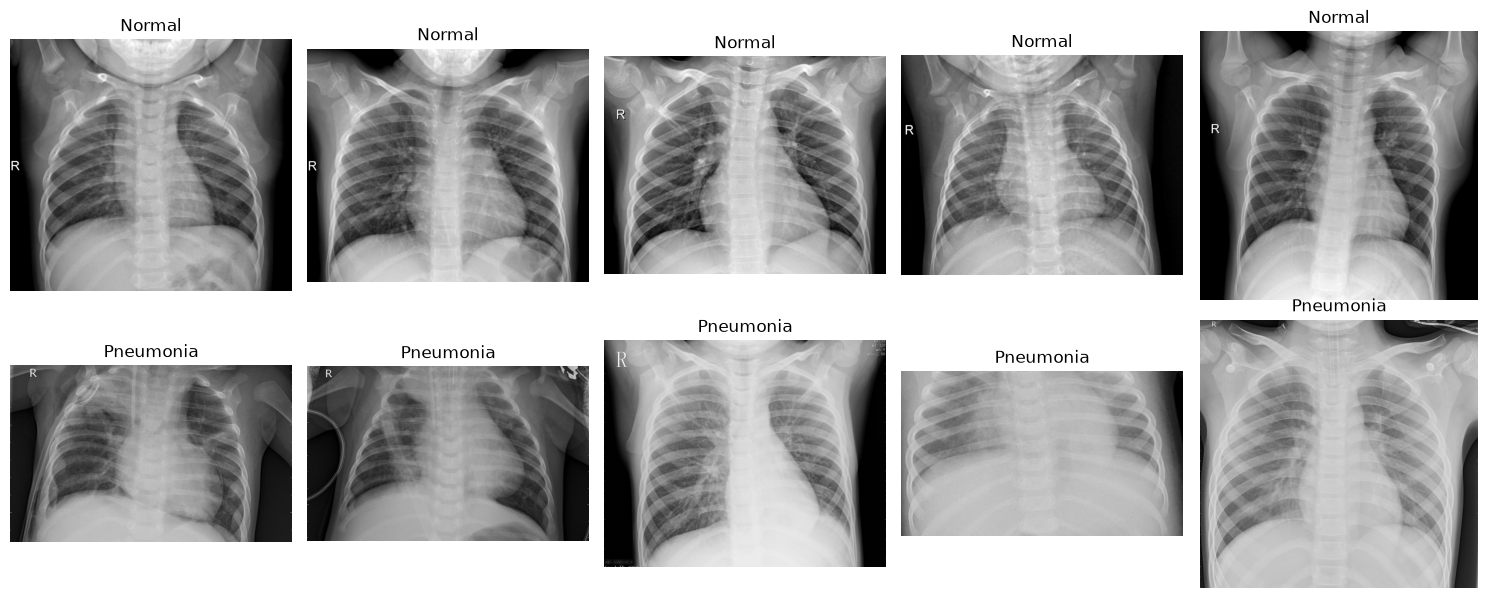

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, image_path in enumerate(normal_images):
    image = Image.open(image_path)
    axes[0, i].imshow(image, cmap="gray")
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

for i, image_path in enumerate(pneumonia_images):
    image = Image.open(image_path)
    axes[1, i].imshow(image, cmap="gray")
    axes[1, i].set_title("Pneumonia")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [7]:
# Inspect image properties

sample_images = normal_images[:3] + pneumonia_images[:3]

for image_path in sample_images:
    image = Image.open(image_path)

    print(f"File: {image_path.name}")
    print(f"Size: {image.size}")
    print(f"Mode: {image.mode}")
    print(f"Format: {image.format}")
    print("-" * 40)

File: NORMAL2-IM-0807-0001.jpeg
Size: (1496, 1337)
Mode: L
Format: JPEG
----------------------------------------
File: NORMAL2-IM-1254-0001.jpeg
Size: (1828, 1515)
Mode: L
Format: JPEG
----------------------------------------
File: IM-0180-0001.jpeg
Size: (2136, 1650)
Mode: L
Format: JPEG
----------------------------------------
File: person281_bacteria_1330.jpeg
Size: (1008, 632)
Mode: L
Format: JPEG
----------------------------------------
File: person548_bacteria_2298.jpeg
Size: (1072, 664)
Mode: L
Format: JPEG
----------------------------------------
File: person323_virus_656.jpeg
Size: (1808, 1456)
Mode: L
Format: JPEG
----------------------------------------


In [8]:
from collections import Counter

def get_image_sizes(folder):
    sizes = []

    for image_path in folder.glob("*.jpeg"):
        with Image.open(image_path) as img:
            sizes.append(img.size)

    for image_path in folder.glob("*.jpg"):
        with Image.open(image_path) as img:
            sizes.append(img.size)

    return sizes


train_normal_sizes = get_image_sizes(TRAIN_DIR / "NORMAL")
train_pneumonia_sizes = get_image_sizes(TRAIN_DIR / "PNEUMONIA")

all_sizes = train_normal_sizes + train_pneumonia_sizes

print("Total images analyzed:", len(all_sizes))
print("Unique image sizes:", len(set(all_sizes)))
print("Most common sizes:")

for size, count in Counter(all_sizes).most_common(10):
    print(size, "→", count)

Total images analyzed: 5216
Unique image sizes: 4366
Most common sizes:
(1072, 648) → 7
(1080, 728) → 6
(1008, 680) → 5
(976, 672) → 5
(1216, 872) → 5
(992, 592) → 5
(1064, 760) → 5
(1008, 704) → 5
(1304, 968) → 4
(1088, 712) → 4
